# Notebook 7
# Model Evaluation

This notebook evaluates the GRU classifier trained on FFT-processed electricity consumption sequences.

In [6]:
import pickle
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import tensorflow as tf

from classifier.evaluate import (
    compute_metrics,
    print_classification_report,
    plot_training_curves,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall_curve,
)

MODELS_DIR = PROJECT_ROOT / "models"
PLOTS_DIR = PROJECT_ROOT / "plots"

PLOTS_DIR.mkdir(exist_ok=True)

## 1. Load Model

In [7]:
MODEL_PATH = MODELS_DIR / "gru_classifier.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("Loaded model:", MODEL_PATH)

Loaded model: /Users/manavagrawal/Documents/Smart-grid-theft-detection/models/gru_classifier.keras


## 2. Load Test Dataset

In [8]:
X_test = np.load(MODELS_DIR / "X_test.npy")
y_test = np.load(MODELS_DIR / "y_test.npy")

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (6371, 1033, 1)
y_test: (6371,)


In [9]:
import numpy as np

print(np.load(MODELS_DIR / "X_test.npy").shape)
print(np.load(MODELS_DIR / "y_test.npy").shape)

(6371, 1033, 1)
(6371,)


## 3. Generate Predictions

In [10]:
y_prob = model.predict(X_test).flatten()

y_pred = (y_prob >= 0.5).astype(int)

print("Prediction completed.")

200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step
Prediction completed.


## 4. Classification Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

In [11]:
metrics = compute_metrics(
    y_test,
    y_prob,
)

print(metrics)

print()

print_classification_report(
    y_test,
    y_prob,
)

Accuracy  : 0.9157
Precision : 0.7778
Recall    : 0.0503
F1 Score  : 0.0944
ROC-AUC   : 0.7452

              precision    recall  f1-score   support

  Honest (0)       0.92      1.00      0.96      5814
   Theft (1)       0.78      0.05      0.09       557

    accuracy                           0.92      6371
   macro avg       0.85      0.52      0.53      6371
weighted avg       0.90      0.92      0.88      6371



## 5. Confusion Matrix

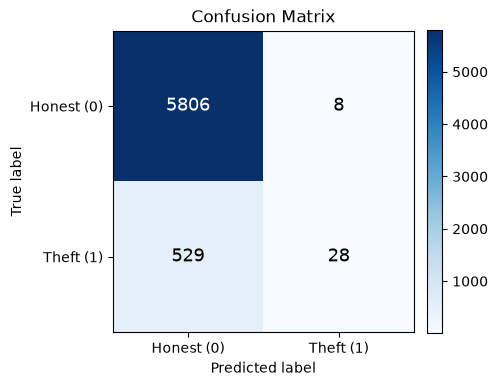

In [12]:
plot_confusion_matrix(
    y_test,
    y_prob,
    save_path=PLOTS_DIR / "confusion_matrix.png",
)

## 6. ROC Curve

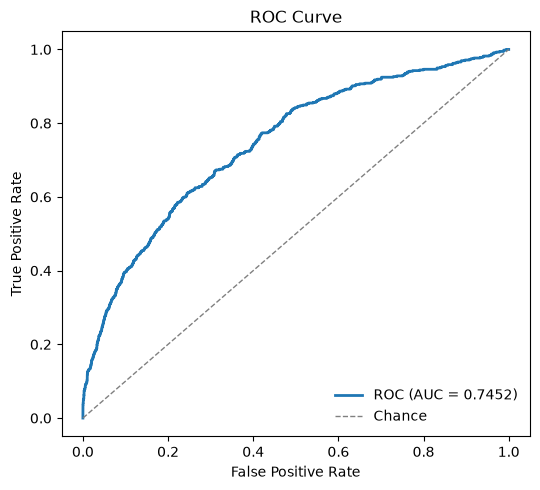

In [13]:
plot_roc_curve(
    y_test,
    y_prob,
    save_path=PLOTS_DIR / "roc_curve.png",
)

## 7. Training Curves

In [14]:
with open(
    MODELS_DIR / "training_history.pkl",
    "rb",
) as f:
    history = pickle.load(f)

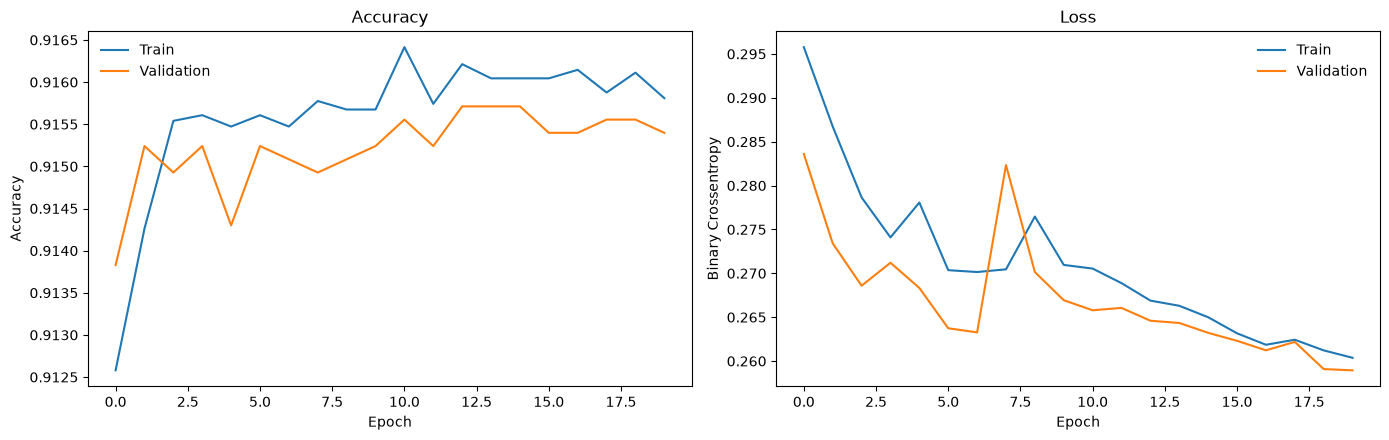

In [15]:
plot_training_curves(
    history,
    save_path=PLOTS_DIR / "training_curves.png",
)

## 8. Precision-Recall Curve

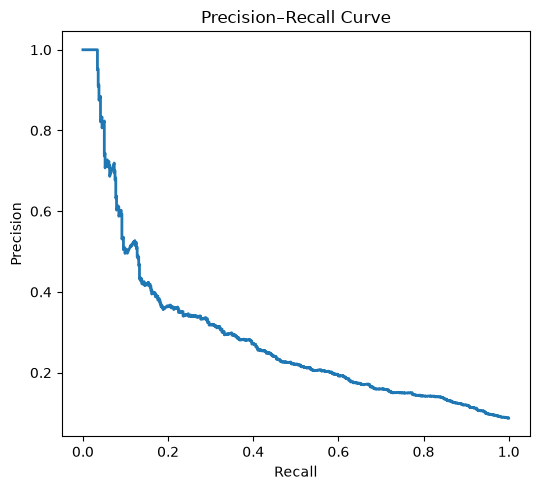

In [16]:
plot_precision_recall_curve(
    y_test,
    y_prob,
    save_path=PLOTS_DIR / "precision_recall_curve.png",
)

FINAL 

The proposed electricity theft detection system integrates TimeGAN-based synthetic data generation, FFT-based signal preprocessing and a GRU classifier. Evaluation using Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix, ROC Curve and Precision–Recall Curve demonstrates the effectiveness of the proposed pipeline. The training curves indicate stable convergence while the evaluation metrics show the model's capability to distinguish between honest and fraudulent electricity consumption patterns.